<a href="https://colab.research.google.com/github/amanbhatia-analyst/credit-card-fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [ ]:
# Download latest version
path = kagglehub.dataset_download("dhanushnarayananr/credit-card-fraud")
# /root/.cache/kagglehub/datasets/dhanushnarayananr/credit-card-fraud/versions/1/card_transdata.csv
print("Path to dataset files:", path)

In [ ]:
# move the dataset to /content/sampledata from /root/.cache/kagglehub/datasets/dhanushnarayananr/credit-card-fraud/versions/1/card_transdata.csv
!mv /root/.cache/kagglehub/datasets/dhanushnarayananr/credit-card-fraud/versions/1/card_transdata.csv /content/sample_data/card_transdata.csv

In [ ]:
data = pd.read_csv("/content/sample_data/card_transdata.csv")

df = pd.DataFrame(data)
df.head()

In [ ]:
df.columns

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print(df.duplicated().sum())

# Check data types
print(df.dtypes)

In [ ]:
# Distribution of Target Variable (Fraud)
plt.figure(figsize=(6, 6))
sns.countplot(x='fraud', data=df, palette='Set2')
plt.title("Distribution of Fraudulent Transactions")
plt.xlabel("Fraud (1 = Fraud, 0 = Not Fraud)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Boxplots for Numerical Features
numerical_features = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

plt.figure(figsize=(12, 6))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='fraud', y=feature, data=df, palette='Set3')
    plt.title(f"Boxplot of {feature}")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize numerical features
scaler = StandardScaler()
df[['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']] = scaler.fit_transform(
    df[['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']]
)

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('fraud', axis=1)
y = df['fraud']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
knn_model = KNeighborsClassifier()
linear_model = LinearRegression()

# Train models
dt_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
linear_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Function to evaluate classification models
def evaluate_classification_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {model_name}:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")

# Function to evaluate Linear Regression (with binary conversion)
def evaluate_linear_regression(model, X_test, y_test):
    y_pred_continuous = model.predict(X_test)
    y_pred_binary = [1 if pred >= 0.5 else 0 for pred in y_pred_continuous]  # Convert to binary
    print("Evaluation for Linear Regression (converted to binary):")
    print("Accuracy:", accuracy_score(y_test, y_pred_binary))
    print("Precision:", precision_score(y_test, y_pred_binary))
    print("Recall:", recall_score(y_test, y_pred_binary))
    print("F1-Score:", f1_score(y_test, y_pred_binary))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_binary))
    print("\n")

# Evaluate Decision Tree
evaluate_classification_model(dt_model, X_test, y_test, "Decision Tree")

# Evaluate KNN
evaluate_classification_model(knn_model, X_test, y_test, "KNN")

# Evaluate Linear Regression
evaluate_linear_regression(linear_model, X_test, y_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune Decision Tree
param_grid_dt = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(dt_model, param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)
print("Best Decision Tree Parameters:", grid_dt.best_params_)

# Tune KNN
param_grid_knn = {'n_neighbors': [3, 5, 7, 9]}
grid_knn = GridSearchCV(knn_model, param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)
print("Best KNN Parameters:", grid_knn.best_params_)

Best Decision Tree Parameters: {'max_depth': 7, 'min_samples_split': 2}
Best KNN Parameters: {'n_neighbors': 3}


In [ ]:
# Evaluate tuned models
print("Tuned Decision Tree:")
evaluate_classification_model(grid_dt.best_estimator_, X_test, y_test, "Tuned Decision Tree")

print("Tuned KNN:")
evaluate_classification_model(grid_knn.best_estimator_, X_test, y_test, "Tuned KNN")


print("Linear Regression:")
evaluate_linear_regression(linear_model, X_test, y_test)

Tuned Decision Tree:
Evaluation for Tuned Decision Tree:
Accuracy: 0.999985
Precision: 0.9999426671253296
Recall: 0.9998853408243995
F1-Score: 0.9999140031532178
Confusion Matrix:
 [[182556      1]
 [     2  17441]]


Tuned KNN:
Evaluation for Tuned KNN:
Accuracy: 0.99874
Precision: 0.9931722990418268
Recall: 0.9923751648225649
F1-Score: 0.9927735719201651
Confusion Matrix:
 [[182438    119]
 [   133  17310]]


Linear Regression:
Evaluation for Linear Regression (converted to binary):
Accuracy: 0.9216
Precision: 0.7283087283087283
Recall: 0.16121080089434156
F1-Score: 0.26398798347728125
Confusion Matrix:
 [[181508   1049]
 [ 14631   2812]]




<Figure size 600x600 with 0 Axes>

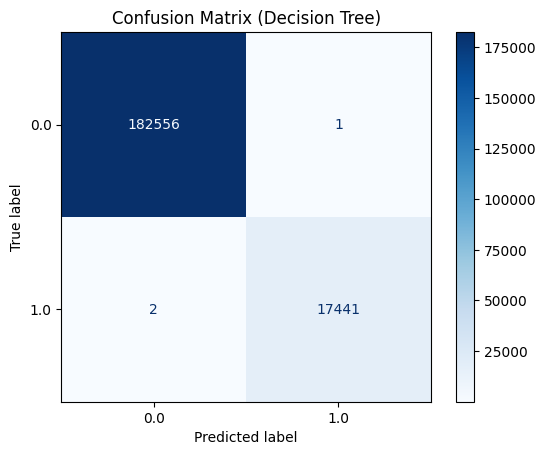

<Figure size 600x600 with 0 Axes>

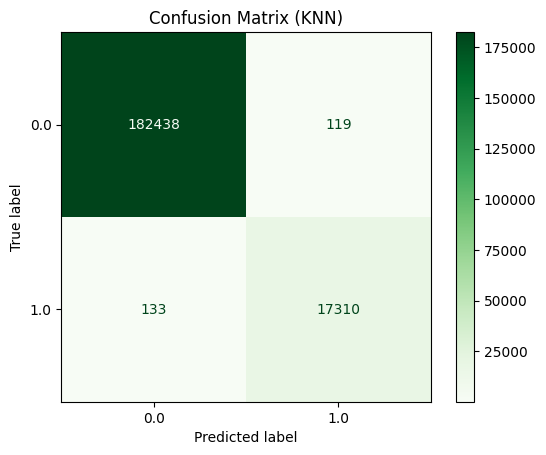

<Figure size 600x600 with 0 Axes>

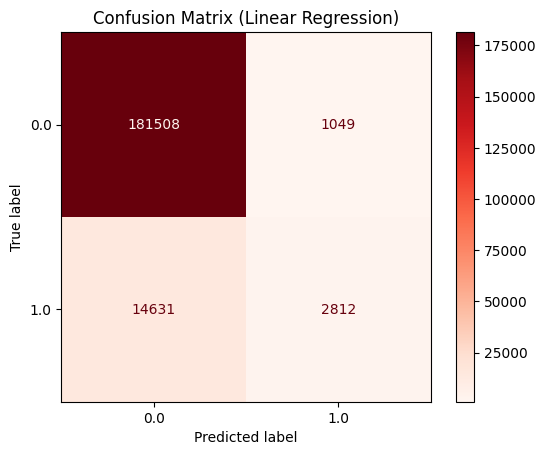

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Decision Tree
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(grid_dt.best_estimator_, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

# Confusion Matrix for KNN
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(grid_knn.best_estimator_, X_test, y_test, cmap='Greens')
plt.title("Confusion Matrix (KNN)")
plt.show()

# Confusion Matrix for Linear Regression (converted to binary)
y_pred_linear_binary = [1 if pred >= 0.5 else 0 for pred in linear_model.predict(X_test)]
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_linear_binary, cmap='Reds')
plt.title("Confusion Matrix (Linear Regression)")
plt.show()

## Feature Importance for Decision Tree

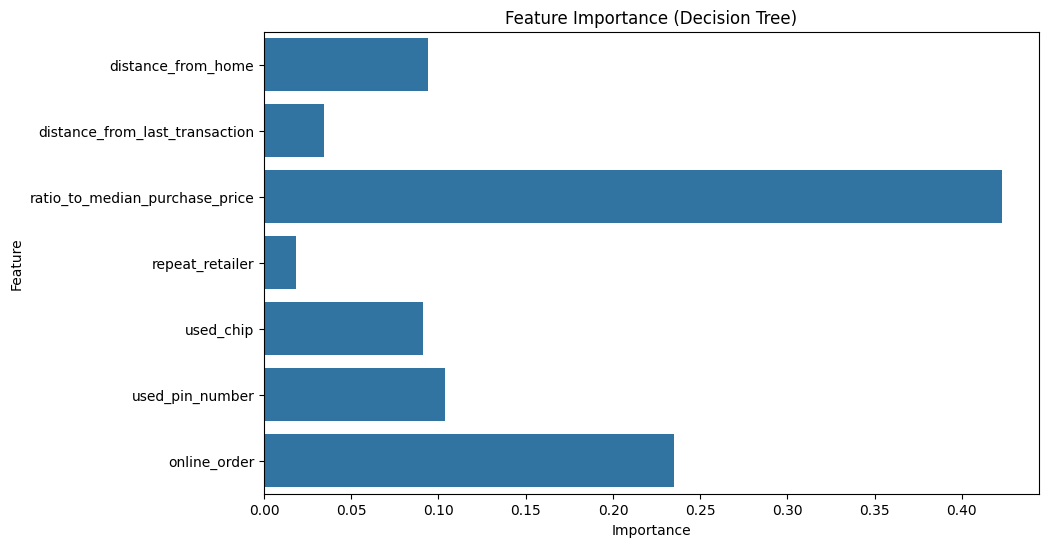

In [ ]:
# Feature Importance for Decision Tree
feature_importances = grid_dt.best_estimator_.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

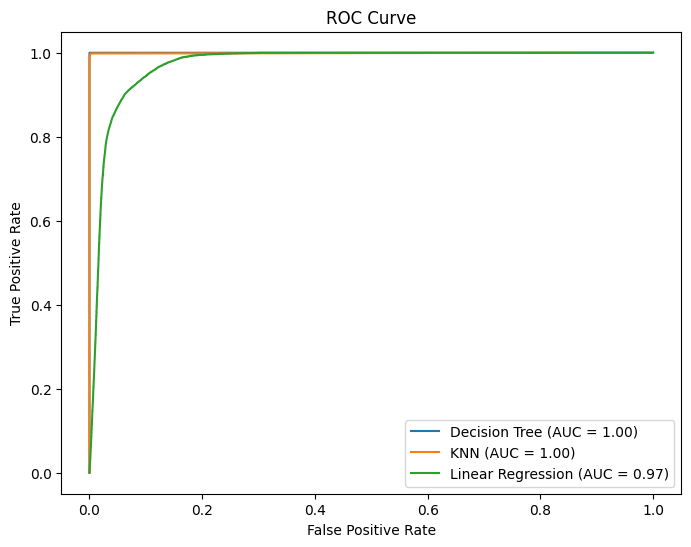

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Function to plot ROC curve#
def plot_roc_curve(model, X_test, y_test, label):
    if hasattr(model, "predict_proba"):  # For Decision Tree and KNN
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:  # For Linear Regression
        y_pred_prob = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

# Plot ROC curves
plt.figure(figsize=(8, 6))
plot_roc_curve(grid_dt.best_estimator_, X_test, y_test, "Decision Tree")
plot_roc_curve(grid_knn.best_estimator_, X_test, y_test, "KNN")
plot_roc_curve(linear_model, X_test, y_test, "Linear Regression")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Function to plot Precision-Recall Curve
def plot_precision_recall_curve(model, X_test, y_test, label):
    if hasattr(model, "predict_proba"):  # For Decision Tree and KNN
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:  # For Linear Regression
        y_pred_prob = model.predict(X_test)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{label} (AUC = {pr_auc:.2f})')

# Plot Precision-Recall Curves
plt.figure(figsize=(8, 6))
plot_precision_recall_curve(grid_dt.best_estimator_, X_test, y_test, "Decision Tree")
plot_precision_recall_curve(grid_knn.best_estimator_, X_test, y_test, "KNN")
plot_precision_recall_curve(linear_model, X_test, y_test, "Linear Regression")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## Distribution of predictions for Linear Regression

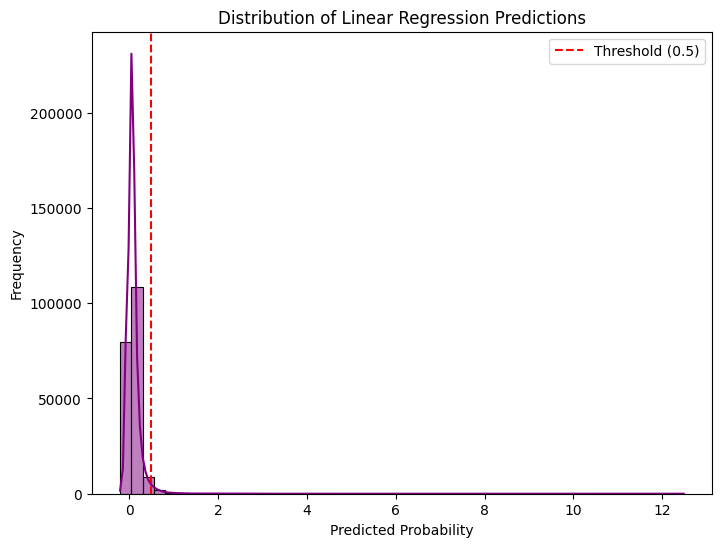

In [ ]:
# Distribution of Linear Regression Predictions
y_pred_linear = linear_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.histplot(y_pred_linear, bins=50, kde=True, color='purple')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.title("Distribution of Linear Regression Predictions")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()